In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from pathlib import Path
path = Path('/content/drive/MyDrive/Datathon_VinTelligence/data/data_clean')
name  = 'Dataset_2_Customer_Insights.csv'
finalpath = path/name
df = pd.read_csv(finalpath)
df.head()

,customer_id,zip,city_x,signup_date,gender,age_group,acquisition_channel,city_y,region,district,Monetary,Frequency,Last_Order_Date,Avg_Rating,Reviews_N
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media,Hai Phong,East,District #13,142803.47,6.0,2021-04-24,0.0,0.0
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign,Hai Phong,East,District #13,204693.89,4.0,2022-07-06,2.0,2.0
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search,Hai Phong,East,District #13,52093.47,3.0,2013-07-29,5.0,1.0
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral,Hai Phong,East,District #13,10939.06,1.0,2020-06-28,0.0,0.0
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search,Hai Phong,East,District #13,64179.86,5.0,2019-03-27,5.0,1.0


## Thiết lập chung

In [6]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import matplotlib.dates as mdates
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
P = ["#4C72B0","#DD8452","#55A868","#C44E52","#9467BD","#8C564B","#E377C2","#7F7F7F"]
df['signup_date']     = pd.to_datetime(df['signup_date'])
df['Last_Order_Date'] = pd.to_datetime(df['Last_Order_Date'])
ref = df['Last_Order_Date'].dropna().max() + pd.Timedelta(days=1)
df['Recency'] = (ref - df['Last_Order_Date']).dt.days
df['Recency']   = df['Recency'].fillna(df['Recency'].max() * 2)
df['Frequency'] = df['Frequency'].fillna(0)
df['Monetary']  = df['Monetary'].fillna(0)

print("Shape:", df.shape)
print(df[['Recency','Frequency','Monetary','Avg_Rating','Reviews_N']].describe().round(2))

Shape: (121930, 16)
         Recency  Frequency    Monetary  Avg_Rating  Reviews_N
count  121930.00  121930.00   121930.00   121930.00  121930.00
mean     2921.23       5.31   128605.51        1.57       0.93
std      2947.28       8.06   202869.81        2.02       1.70
min         1.00       0.00        0.00        0.00       0.00
25%       536.00       0.00        0.00        0.00       0.00
50%      1680.00       2.00    44348.41        0.00       0.00
75%      7666.00       7.00   166295.70        4.00       1.00
max      7666.00     107.00  3503583.41        5.00      23.00


## 1. Phân tích RFM (Recency – Frequency – Monetary)

### 1.1  Phân phối R / F / M

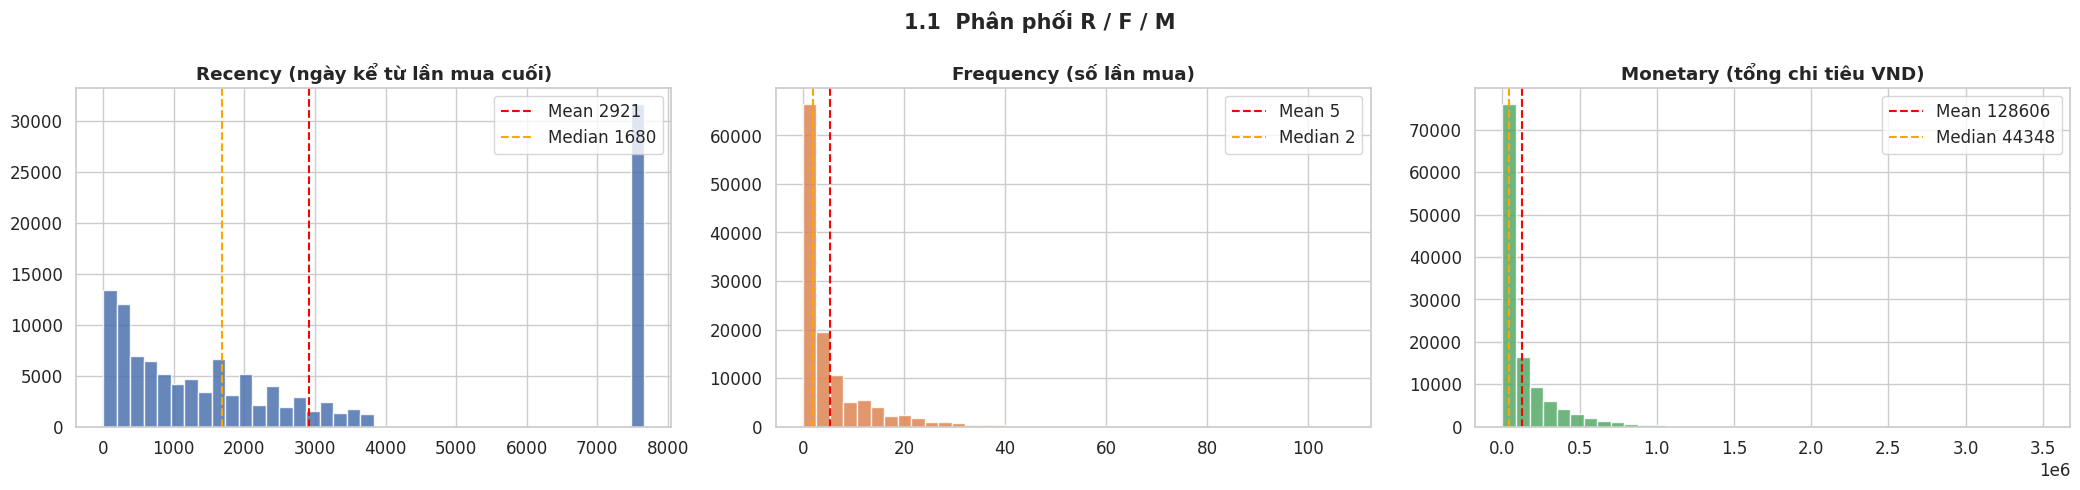

⚠  Khách có signup_date SAU Last_Order_Date: 41,537 (34.1%)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

for ax, col, label, c in zip(
    axes,
    ['Recency','Frequency','Monetary'],
    ['Recency (ngày kể từ lần mua cuối)','Frequency (số lần mua)','Monetary (tổng chi tiêu VND)'],
    P[:3]
):
    ax.hist(df[col].dropna(), bins=40, color=c, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='red',    ls='--', lw=1.5, label=f'Mean {df[col].mean():.0f}')
    ax.axvline(df[col].median(), color='orange', ls='--', lw=1.5, label=f'Median {df[col].median():.0f}')
    ax.set_title(label, fontweight='bold'); ax.legend()

fig.suptitle("1.1  Phân phối R / F / M", fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

# Data quality: signup_date > Last_Order_Date
bad = (df['signup_date'] > df['Last_Order_Date']).sum()
print(f"⚠  Khách có signup_date SAU Last_Order_Date: {bad:,} ({bad/len(df)*100:.1f}%)")

### 1.2  Chấm điểm & Phân khúc RFM

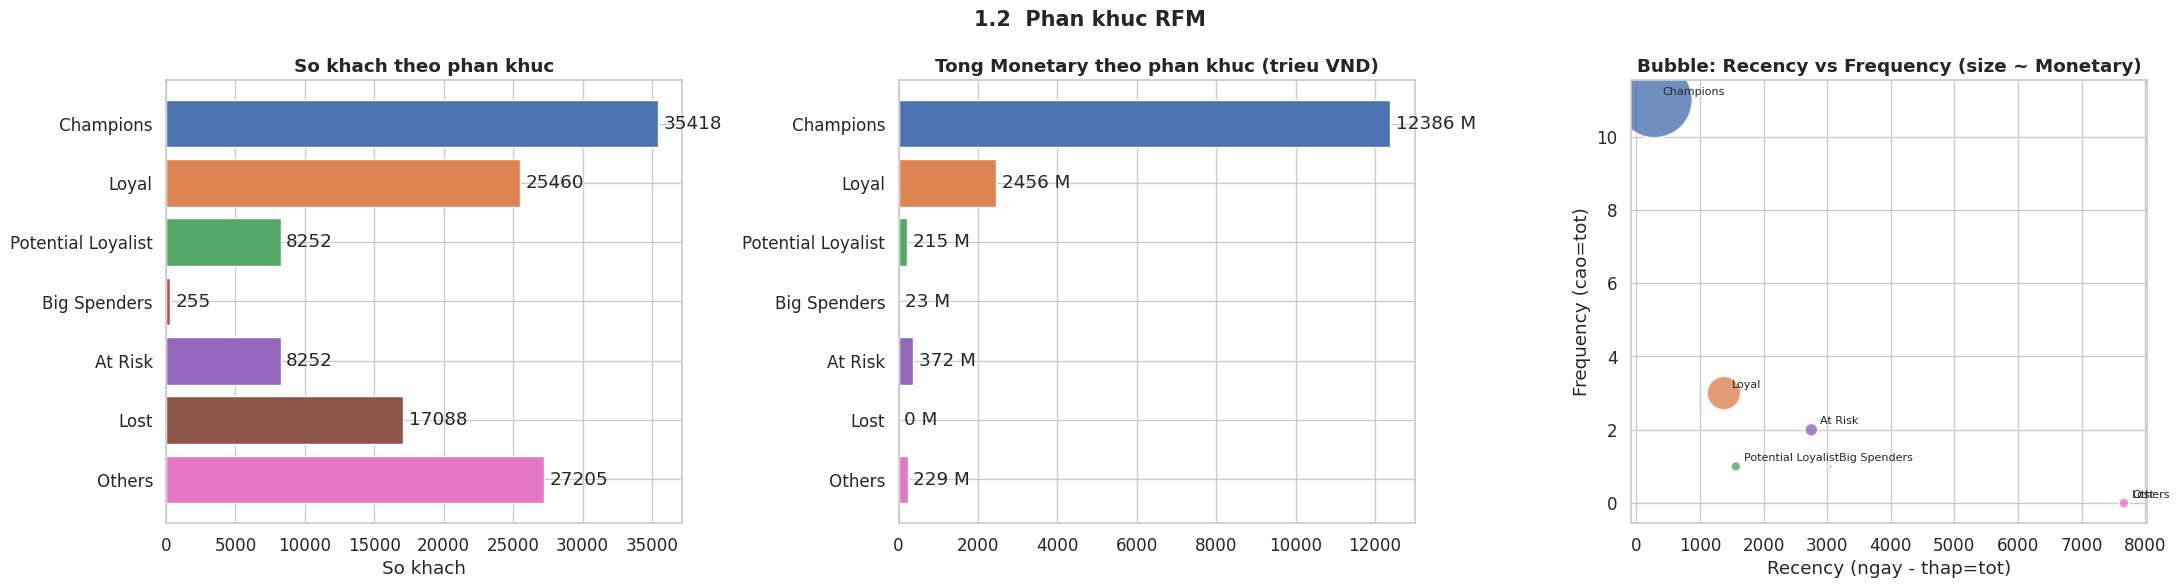


 Phan khuc RFM:
                    so_khach  monetary_tb  frequency_tb  recency_tb
RFM_Segment                                                        
Champions              35418     349698.0          14.0       398.0
Loyal                  25460      96478.0           4.0      1281.0
Potential Loyalist      8252      26104.0           1.0      1358.0
Big Spenders             255      90795.0           1.0      3027.0
At Risk                 8252      45053.0           2.0      2834.0
Lost                   17088          0.0           0.0      7666.0
Others                 27205       8403.0           1.0      5260.0


In [8]:
def pct_score(series, n=5, reverse=False):
    pct = series.rank(method='first', na_option='bottom', pct=True)
    score = __import__('numpy').ceil(pct * n).astype(int).clip(1, n)
    return (n + 1 - score) if reverse else score

df['R_score'] = pct_score(df['Recency'],   reverse=True)
df['F_score'] = pct_score(df['Frequency'], reverse=False)
df['M_score'] = pct_score(df['Monetary'],  reverse=False)
df['RFM_Total'] = df['R_score'] + df['F_score'] + df['M_score']
def segment(r):
    R, F, M = r['R_score'], r['F_score'], r['M_score']
    if R>=4 and F>=4 and M>=4: return 'Champions'
    if R>=3 and F>=3 and M>=3: return 'Loyal'
    if R>=3 and F<=2:           return 'Potential Loyalist'
    if R<=2 and F>=3:           return 'At Risk'
    if R==1 and F==1:           return 'Lost'
    if M>=4:                    return 'Big Spenders'
    return 'Others'
df['RFM_Segment'] = df.apply(segment, axis=1)
SEG_ORDER  = ['Champions','Loyal','Potential Loyalist','Big Spenders','At Risk','Lost','Others']
SEG_COLORS = dict(zip(SEG_ORDER, P))
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

ax = axes[0]
cnt = df['RFM_Segment'].value_counts().reindex(SEG_ORDER).dropna()
bars = ax.barh(cnt.index, cnt.values, color=[SEG_COLORS[s] for s in cnt.index], edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=4)
ax.set_title('So khach theo phan khuc', fontweight='bold')
ax.set_xlabel('So khach'); ax.invert_yaxis()

ax = axes[1]
mon = df.groupby('RFM_Segment')['Monetary'].sum().reindex(SEG_ORDER).dropna() / 1e6
bars2 = ax.barh(mon.index, mon.values, color=[SEG_COLORS[s] for s in mon.index], edgecolor='white')
ax.bar_label(bars2, fmt='%.0f M', padding=4)
ax.set_title('Tong Monetary theo phan khuc (trieu VND)', fontweight='bold')
ax.invert_yaxis()

ax = axes[2]
agg = df.groupby('RFM_Segment').agg(R=('Recency','median'), F=('Frequency','median'), M=('Monetary','sum')).reindex(SEG_ORDER).dropna()
ax.scatter(agg['R'], agg['F'], s=agg['M']/agg['M'].max()*3000, c=[SEG_COLORS[s] for s in agg.index], alpha=0.8, edgecolors='white', linewidth=1.5)
for seg, row in agg.iterrows():
    ax.annotate(seg, (row['R'], row['F']), textcoords='offset points', xytext=(6,4), fontsize=8)
ax.set_xlabel('Recency (ngay - thap=tot)'); ax.set_ylabel('Frequency (cao=tot)')
ax.set_title('Bubble: Recency vs Frequency (size ~ Monetary)', fontweight='bold')

fig.suptitle('1.2  Phan khuc RFM', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n Phan khuc RFM:')
summary = df.groupby('RFM_Segment').agg(so_khach=('customer_id','count'), monetary_tb=('Monetary','mean'), frequency_tb=('Frequency','mean'), recency_tb=('Recency','mean')).reindex(SEG_ORDER).dropna().round(0)
print(summary.to_string())

## 2. Chân dung & Địa lý (Demographics & Geo)

### 2.1  Phân tích theo Thành phố & Khu vực

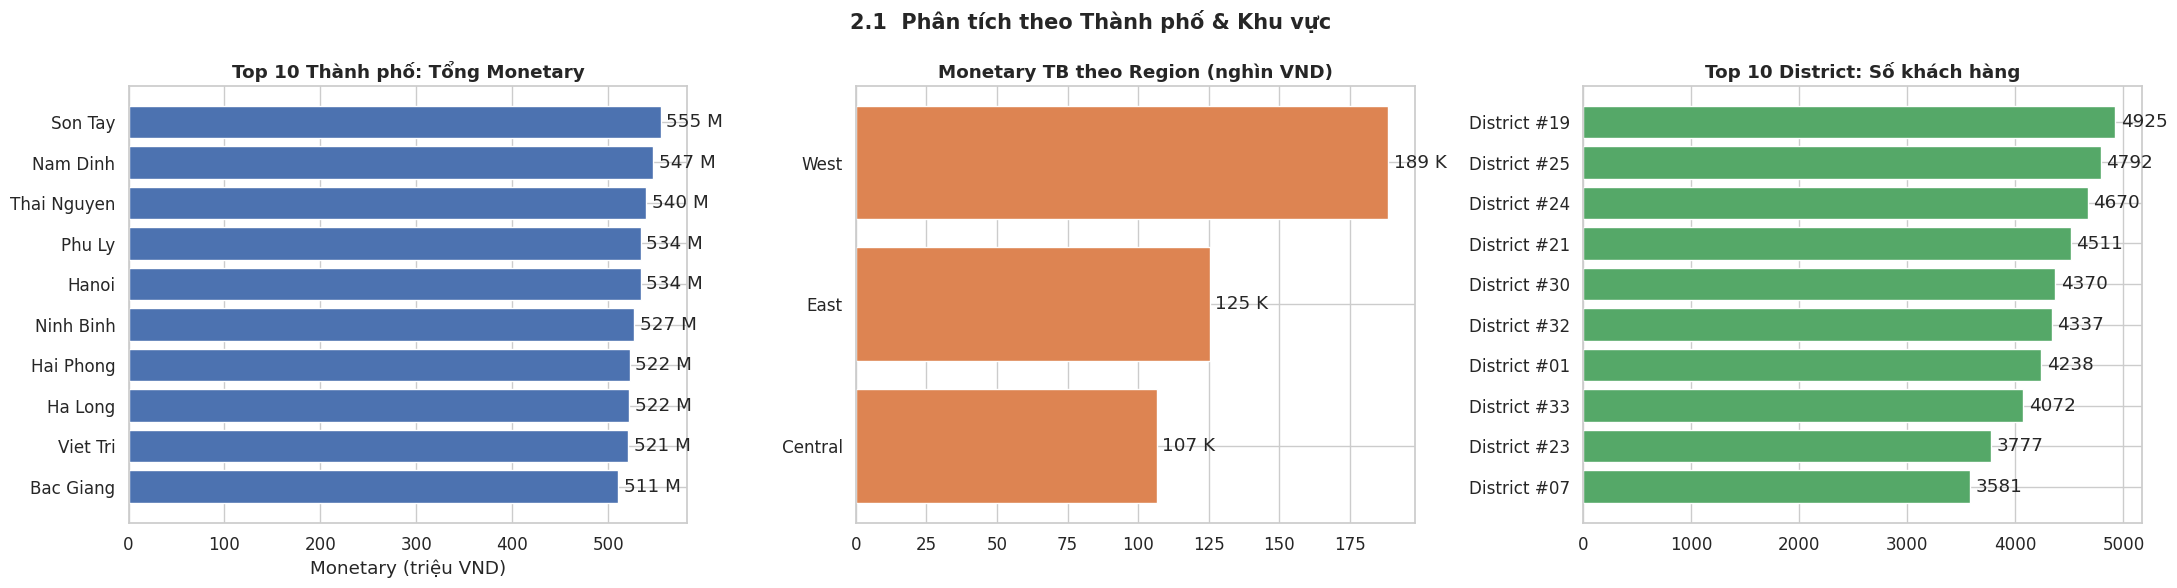

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
ax = axes[0]
top_city = df.groupby('city_y')['Monetary'].sum().nlargest(10).sort_values() / 1e6
ax.barh(top_city.index, top_city.values, color=P[0], edgecolor='white')
ax.bar_label(ax.containers[0], fmt='%.0f M', padding=4)
ax.set_title("Top 10 Thành phố: Tổng Monetary", fontweight='bold')
ax.set_xlabel("Monetary (triệu VND)")

ax = axes[1]
reg = df.groupby('region')['Monetary'].mean().sort_values() / 1e3
ax.barh(reg.index, reg.values, color=P[1], edgecolor='white')
ax.bar_label(ax.containers[0], fmt='%.0f K', padding=4)
ax.set_title("Monetary TB theo Region (nghìn VND)", fontweight='bold')

ax = axes[2]
dist = df.groupby('district')['customer_id'].count().nlargest(10).sort_values()
ax.barh(dist.index, dist.values, color=P[2], edgecolor='white')
ax.bar_label(ax.containers[0], fmt='%d', padding=4)
ax.set_title("Top 10 District: Số khách hàng", fontweight='bold')
fig.suptitle("2.1  Phân tích theo Thành phố & Khu vực", fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

### 2.2  Giới tính & Độ tuổi

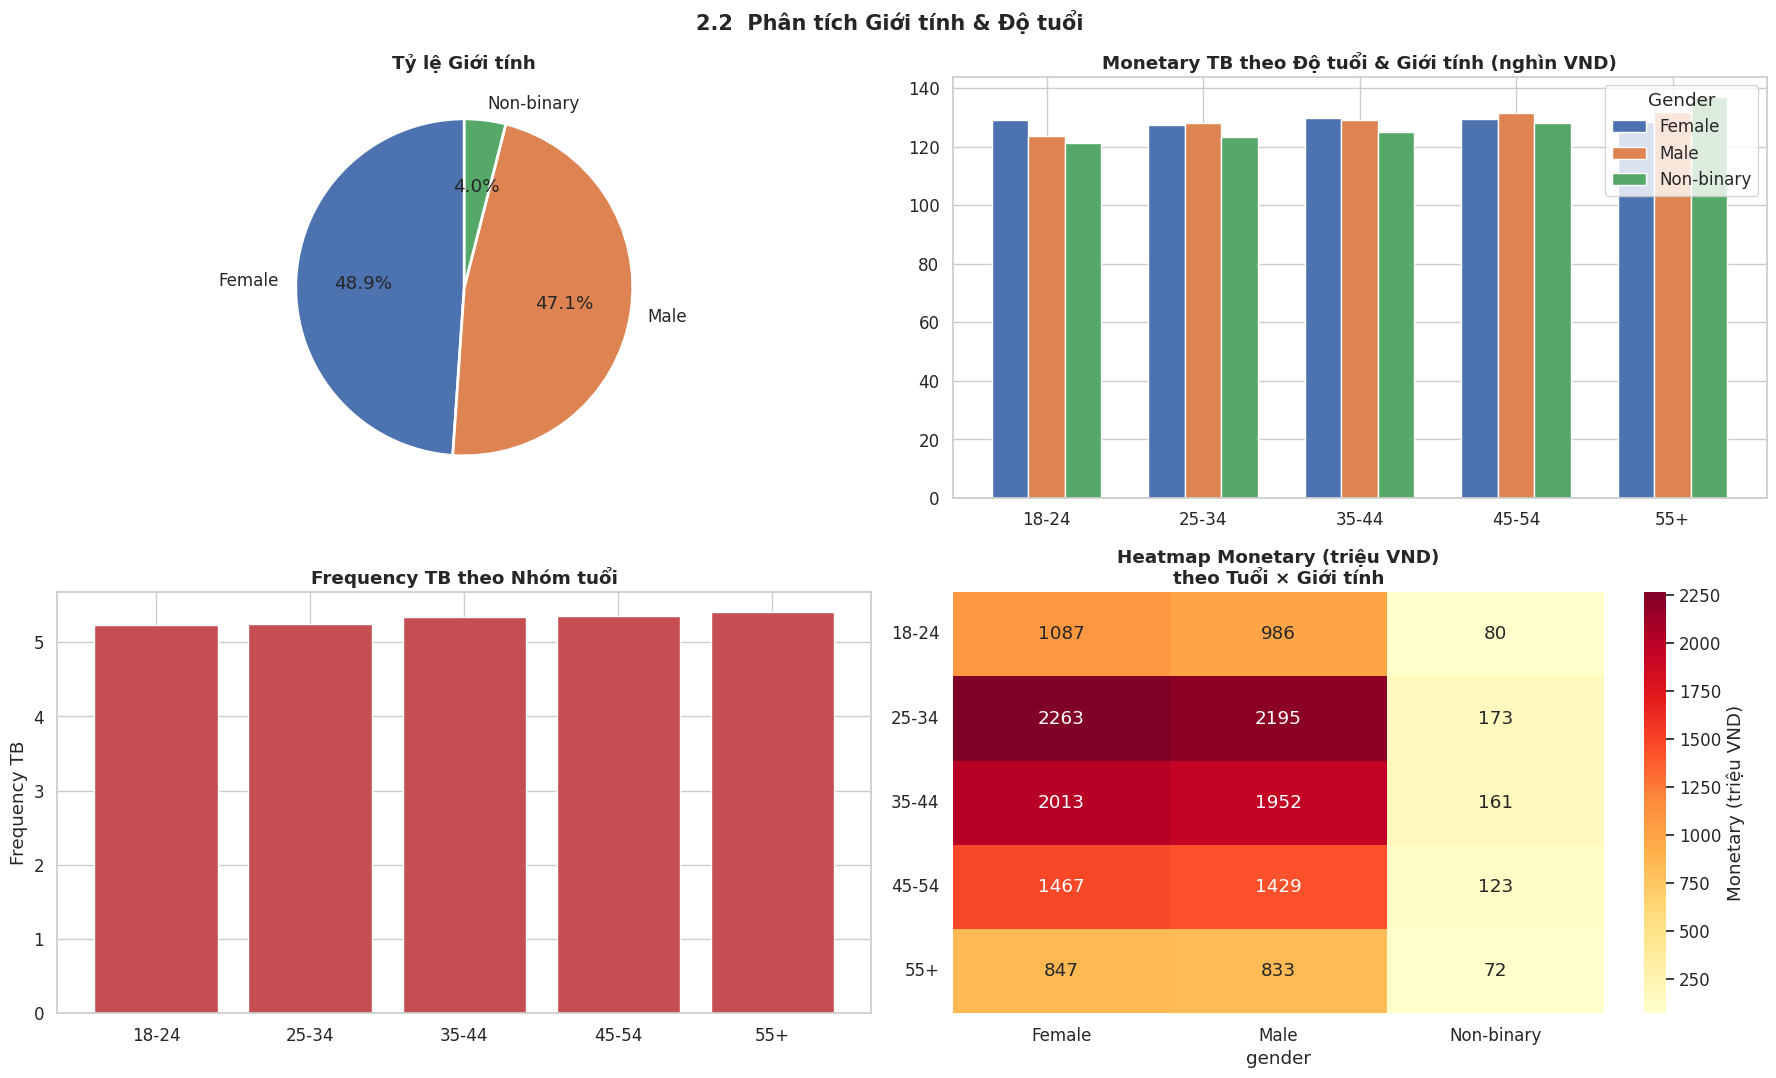

In [10]:
AGE_ORDER = ['18-24','25-34','35-44','45-54','55+']
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
ax = axes[0,0]
gc = df['gender'].value_counts()
ax.pie(gc.values, labels=gc.index, colors=P[:len(gc)],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title("Tỷ lệ Giới tính", fontweight='bold')

ax = axes[0,1]
pivot = df.pivot_table('Monetary','age_group','gender',
                        aggfunc='mean').reindex(AGE_ORDER) / 1e3
pivot.plot(kind='bar', ax=ax, color=P[:pivot.shape[1]], edgecolor='white', width=0.7)
ax.set_title("Monetary TB theo Độ tuổi & Giới tính (nghìn VND)", fontweight='bold')
ax.set_xlabel(""); ax.tick_params(axis='x', rotation=0)
ax.legend(title='Gender')

# (c) Frequency TB theo age_group
ax = axes[1,0]
fr_age = df.groupby('age_group')['Frequency'].mean().reindex(AGE_ORDER)
ax.bar(fr_age.index, fr_age.values, color=P[3], edgecolor='white')
ax.set_title("Frequency TB theo Nhóm tuổi", fontweight='bold')
ax.set_ylabel("Frequency TB")

# (d) Heatmap: age_group × gender → Monetary
ax = axes[1,1]
hm = df.pivot_table('Monetary','age_group','gender',
                     aggfunc='sum').reindex(AGE_ORDER) / 1e6
sns.heatmap(hm, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label':'Monetary (triệu VND)'})
ax.set_title("Heatmap Monetary (triệu VND)\ntheo Tuổi × Giới tính", fontweight='bold')
ax.set_ylabel(""); ax.tick_params(axis='y', rotation=0)

fig.suptitle("2.2  Phân tích Giới tính & Độ tuổi", fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Hiệu quả Kênh Marketing (Acquisition Channel)

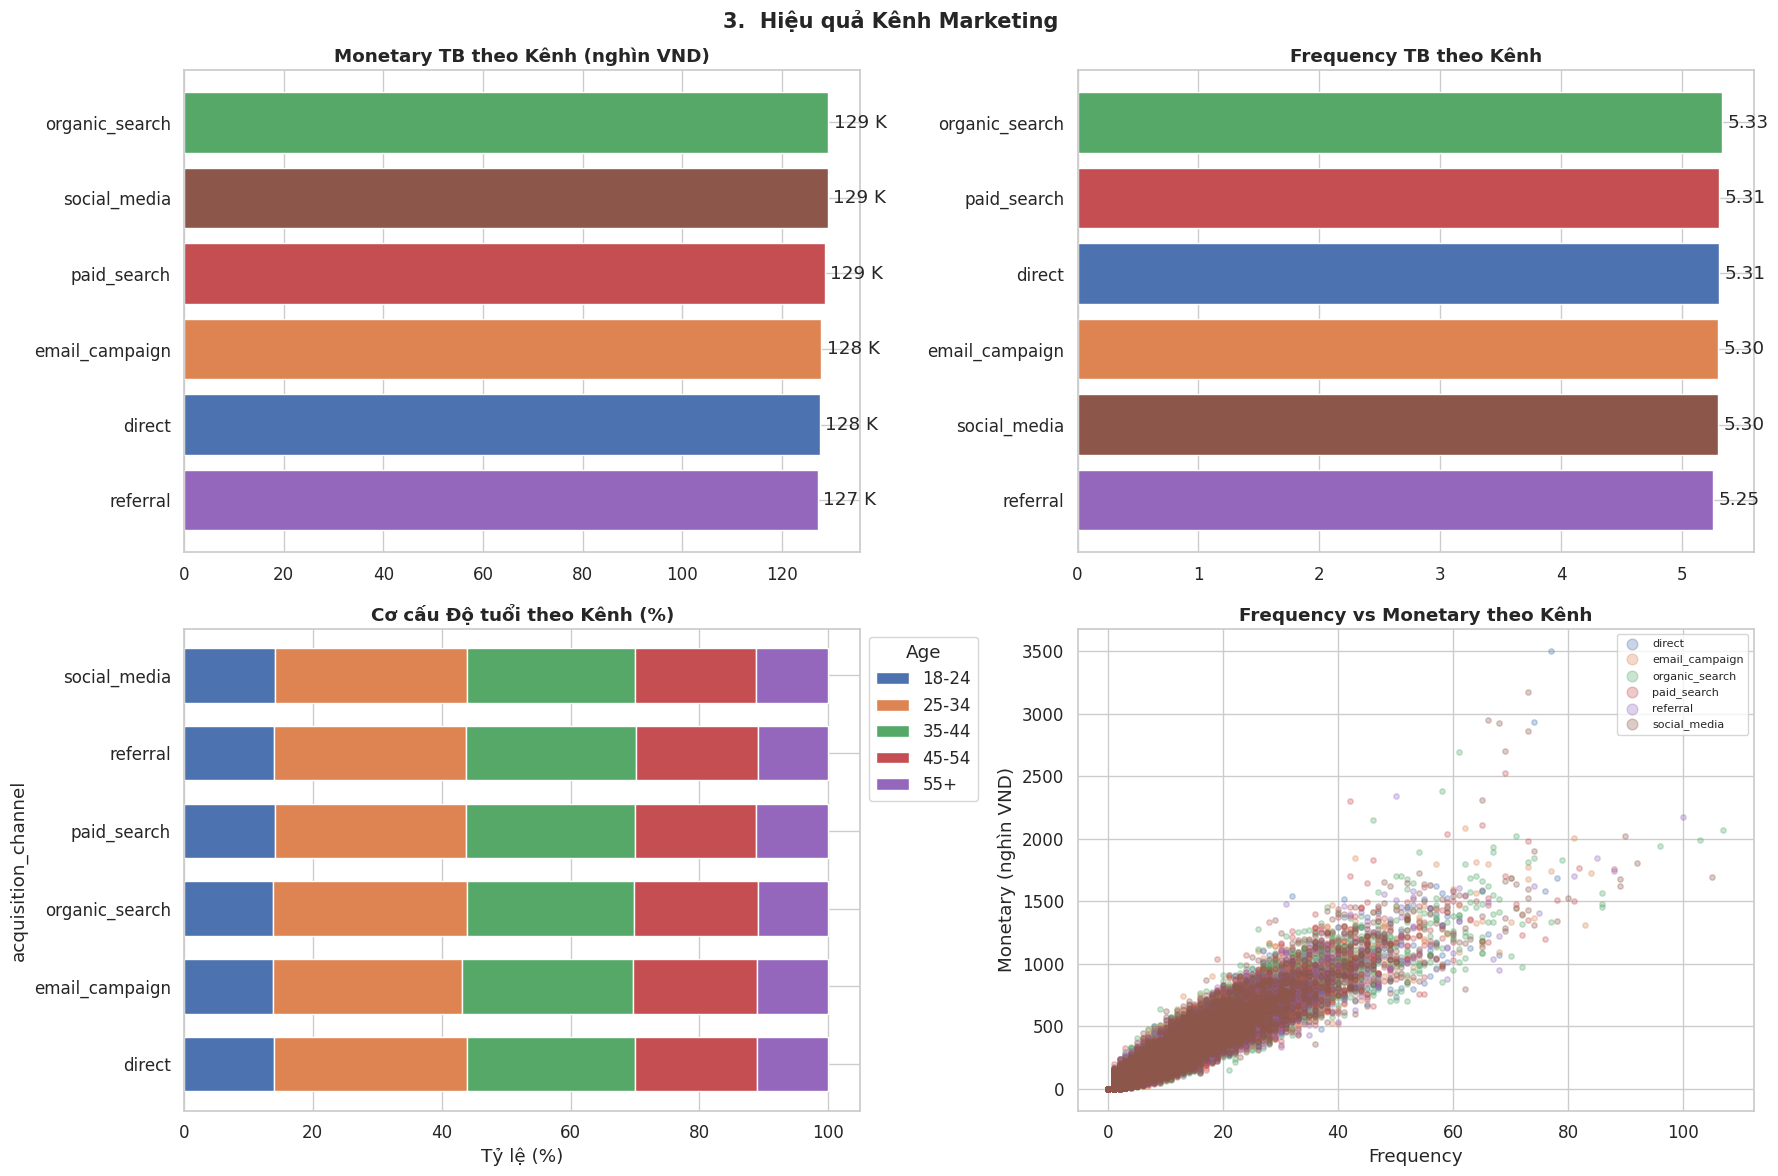


📊 Bảng tổng hợp theo kênh:
                     so_khach  monetary_tb  frequency_tb  pct_champions
acquisition_channel                                                    
organic_search          36450     129278.1           5.3           29.1
social_media            24448     129196.6           5.3           29.3
paid_search             24285     128572.3           5.3           28.9
email_campaign          14674     127906.9           5.3           28.7
direct                   9803     127595.3           5.3           29.5
referral                12270     127137.9           5.3           28.8


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
channels = df['acquisition_channel'].unique()
ch_colors = dict(zip(sorted(channels), P[:len(channels)]))

ax = axes[0,0]
ch_mon = df.groupby('acquisition_channel')['Monetary'].mean().sort_values() / 1e3
ax.barh(ch_mon.index, ch_mon.values,
        color=[ch_colors.get(c, P[0]) for c in ch_mon.index], edgecolor='white')
ax.bar_label(ax.containers[0], fmt='%.0f K', padding=4)
ax.set_title("Monetary TB theo Kênh (nghìn VND)", fontweight='bold')
ax = axes[0,1]
ch_frq = df.groupby('acquisition_channel')['Frequency'].mean().sort_values()
ax.barh(ch_frq.index, ch_frq.values,
        color=[ch_colors.get(c, P[1]) for c in ch_frq.index], edgecolor='white')
ax.bar_label(ax.containers[0], fmt='%.2f', padding=4)
ax.set_title("Frequency TB theo Kênh", fontweight='bold')

ax = axes[1,0]
ct = pd.crosstab(df['acquisition_channel'], df['age_group'])
ct = ct[['18-24','25-34','35-44','45-54','55+']]
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='barh', stacked=True, ax=ax, color=P[:5],
            edgecolor='white', width=0.7)
ax.set_title("Cơ cấu Độ tuổi theo Kênh (%)", fontweight='bold')
ax.set_xlabel("Tỷ lệ (%)"); ax.legend(title='Age', bbox_to_anchor=(1,1))

# (d) Scatter Monetary vs Frequency theo kênh
ax = axes[1,1]
for ch in sorted(df['acquisition_channel'].unique()):
    sub = df[df['acquisition_channel']==ch]
    ax.scatter(sub['Frequency'], sub['Monetary']/1e3,
               alpha=0.3, s=15, label=ch, color=ch_colors.get(ch, 'gray'))
ax.set_xlabel("Frequency"); ax.set_ylabel("Monetary (nghìn VND)")
ax.set_title("Frequency vs Monetary theo Kênh", fontweight='bold')
ax.legend(fontsize=8, markerscale=2)

fig.suptitle("3.  Hiệu quả Kênh Marketing", fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n Bảng tổng hợp theo kênh:")
ch_summary = df.groupby('acquisition_channel').agg(
    so_khach=('customer_id','count'),
    monetary_tb=('Monetary','mean'),
    frequency_tb=('Frequency','mean'),
    pct_champions=('RFM_Segment', lambda x: (x=='Champions').mean()*100)
).round(1).sort_values('monetary_tb', ascending=False)
print(ch_summary.to_string())

## 4. Trải nghiệm & Lòng trung thành (Experience & Loyalty)

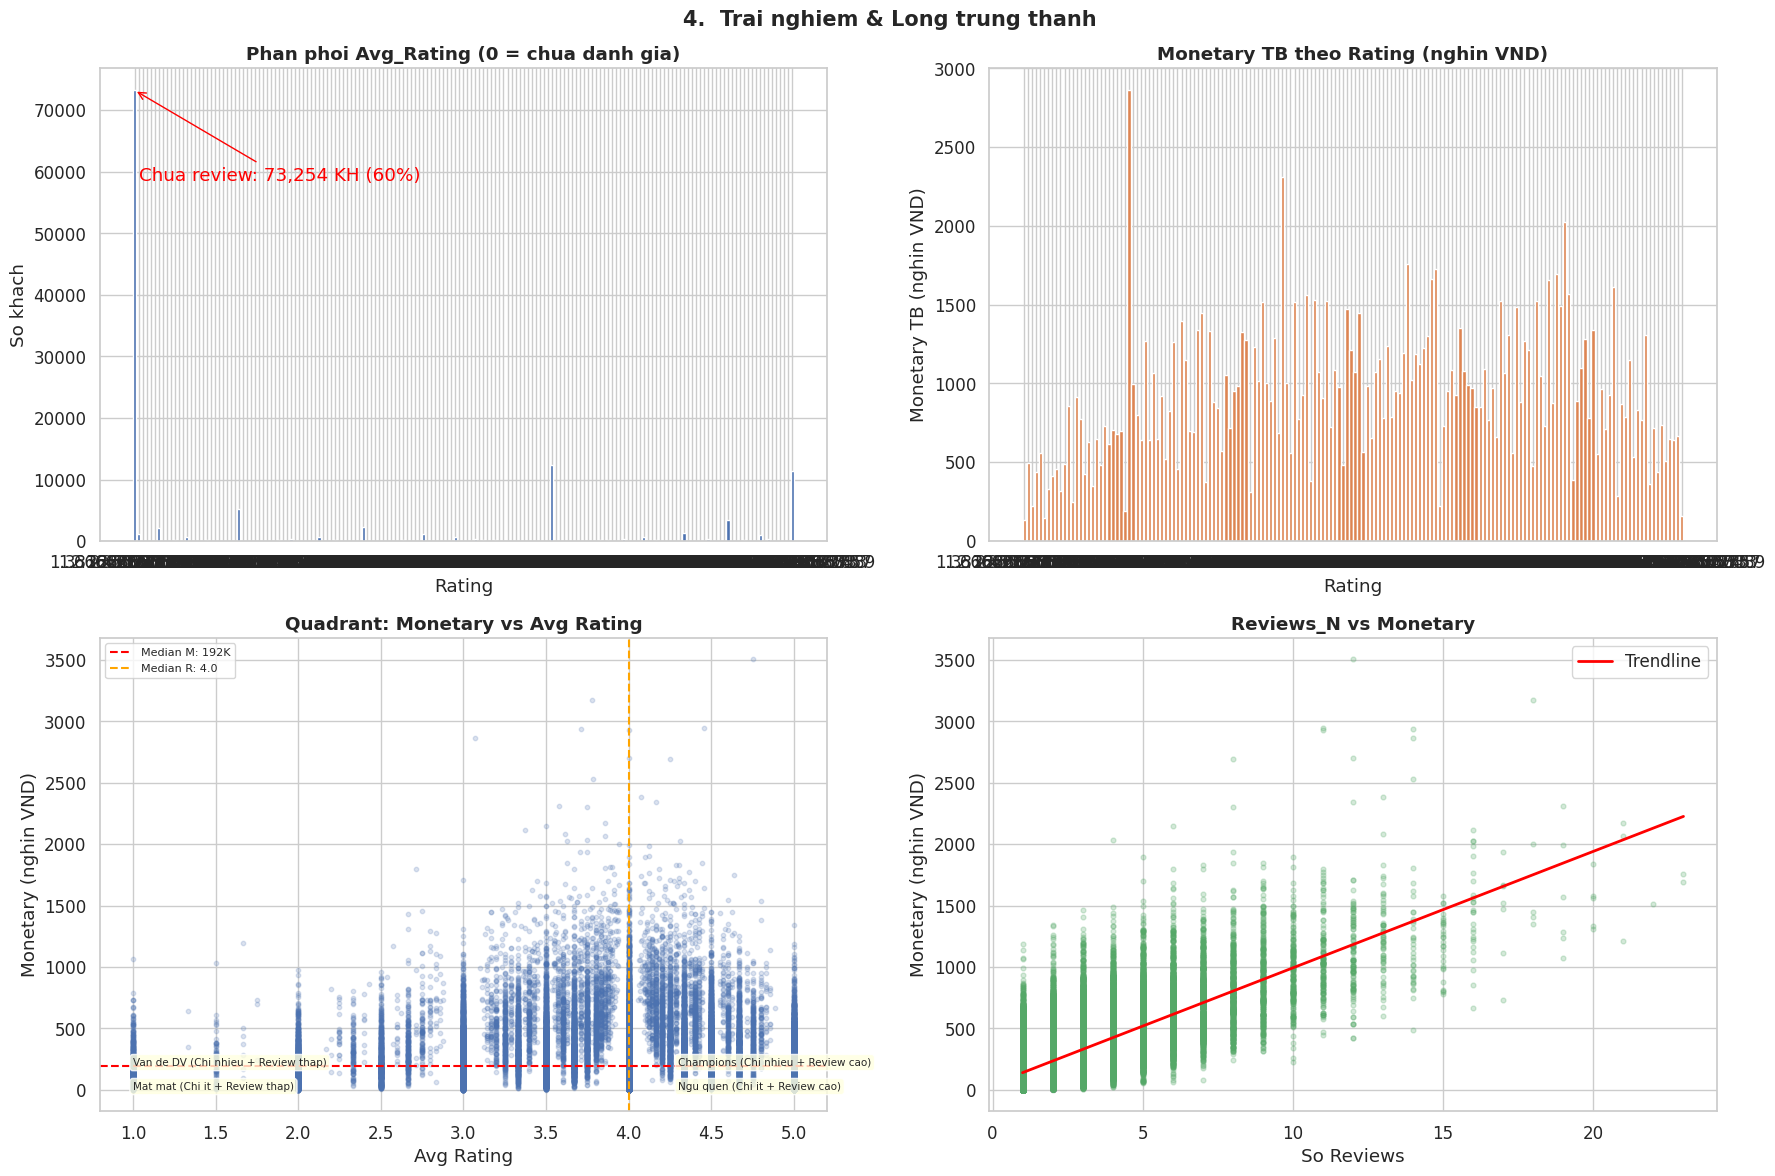

Quadrant Analysis:
  Champions (M+ R+): 15,037 KH (30.9%)
  Van de DV (M+ R-): 9,301 KH (19.1%)
  Ngu quen (M- R+): 16,958 KH (34.8%)
  Mat mat (M- R-): 7,380 KH (15.2%)


In [13]:
df_rated = df[df['Avg_Rating'] > 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

ax = axes[0,0]
rating_cnt = df['Avg_Rating'].value_counts().sort_index()
ax.bar(rating_cnt.index.astype(str), rating_cnt.values, color=P[0], edgecolor='white')
ax.set_title('Phan phoi Avg_Rating (0 = chua danh gia)', fontweight='bold')
ax.set_xlabel('Rating'); ax.set_ylabel('So khach')
no_review = (df['Avg_Rating']==0).sum()
ax.annotate(f'Chua review: {no_review:,} KH ({no_review/len(df)*100:.0f}%)',
            xy=(0, no_review), xytext=(1, no_review*0.8),
            arrowprops=dict(arrowstyle='->', color='red'), color='red')

ax = axes[0,1]
mon_rat = df_rated.groupby('Avg_Rating')['Monetary'].mean() / 1e3
ax.bar(mon_rat.index.astype(str), mon_rat.values, color=P[1], edgecolor='white')
ax.set_title('Monetary TB theo Rating (nghin VND)', fontweight='bold')
ax.set_xlabel('Rating'); ax.set_ylabel('Monetary TB (nghin VND)')

ax = axes[1,0]
m_med = df_rated['Monetary'].median()
r_med = df_rated['Avg_Rating'].median()
ax.scatter(df_rated['Avg_Rating'], df_rated['Monetary']/1e3, alpha=0.2, s=10, color=P[0])
ax.axhline(m_med/1e3, color='red', ls='--', lw=1.5, label=f'Median M: {m_med/1e3:.0f}K')
ax.axvline(r_med, color='orange', ls='--', lw=1.5, label=f'Median R: {r_med:.1f}')
for txt, (xa, ya) in {
    'Champions (Chi nhieu + Review cao)': (r_med+0.3, m_med/1e3+5),
    'Van de DV (Chi nhieu + Review thap)': (1.0, m_med/1e3+5),
    'Ngu quen (Chi it + Review cao)': (r_med+0.3, 2),
    'Mat mat (Chi it + Review thap)': (1.0, 2),
}.items():
    ax.text(xa, ya, txt, fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
ax.set_xlabel('Avg Rating'); ax.set_ylabel('Monetary (nghin VND)')
ax.set_title('Quadrant: Monetary vs Avg Rating', fontweight='bold')
ax.legend(fontsize=8)

ax = axes[1,1]
rev_df = df[df['Reviews_N']>0]
ax.scatter(rev_df['Reviews_N'], rev_df['Monetary']/1e3, alpha=0.25, s=12, color=P[2])
z = __import__('numpy').polyfit(rev_df['Reviews_N'], rev_df['Monetary']/1e3, 1)
xr = __import__('numpy').linspace(rev_df['Reviews_N'].min(), rev_df['Reviews_N'].max(), 100)
ax.plot(xr, __import__('numpy').polyval(z,xr), color='red', lw=2, label='Trendline')
ax.set_xlabel('So Reviews'); ax.set_ylabel('Monetary (nghin VND)')
ax.set_title('Reviews_N vs Monetary', fontweight='bold')
ax.legend()

fig.suptitle('4.  Trai nghiem & Long trung thanh', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

hi_m = df_rated['Monetary'] >= m_med
hi_r = df_rated['Avg_Rating'] >= r_med
print('Quadrant Analysis:')
q = {
    'Champions (M+ R+)': (hi_m & hi_r).sum(),
    'Van de DV (M+ R-)': (hi_m & ~hi_r).sum(),
    'Ngu quen (M- R+)':  (~hi_m & hi_r).sum(),
    'Mat mat (M- R-)':   (~hi_m & ~hi_r).sum(),
}
for k,v in q.items():
    print(f'  {k}: {v:,} KH ({v/len(df_rated)*100:.1f}%)')

## 5. Tổng hợp: RFM Segment × Kênh Marketing

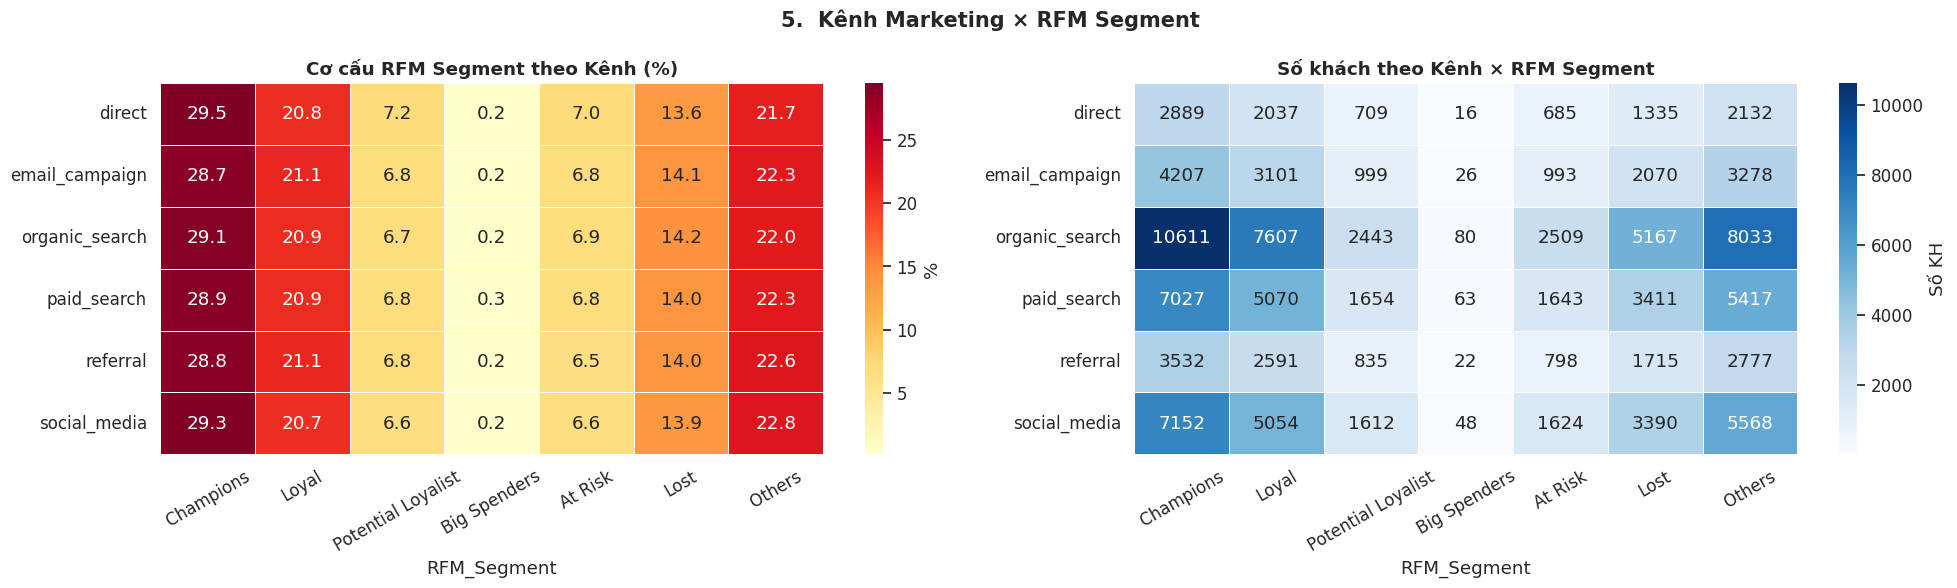

In [14]:
pivot = pd.crosstab(df['acquisition_channel'], df['RFM_Segment'])
pivot = pivot[['Champions','Loyal','Potential Loyalist','Big Spenders','At Risk','Lost','Others']]
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[0], cbar_kws={'label':'%'}, linewidths=0.5)
axes[0].set_title("Cơ cấu RFM Segment theo Kênh (%)", fontweight='bold')
axes[0].set_ylabel(""); axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues',
            ax=axes[1], cbar_kws={'label':'Số KH'}, linewidths=0.5)
axes[1].set_title("Số khách theo Kênh × RFM Segment", fontweight='bold')
axes[1].set_ylabel(""); axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("5.  Kênh Marketing × RFM Segment", fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()